In [1]:
import datetime as dt
import os
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from string import ascii_letters
rs = np.random.RandomState(33)
d = pd.DataFrame(data=rs.normal(size=(100, 26)),
                 columns=list(ascii_letters[26:]))
corr = d.corr()
corr.head()

,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
A,1.000000,-0.107401,-0.086468,0.000131,0.035047,0.004749,0.028226,0.000422,0.132100,0.057720,...,0.073645,-0.055396,-0.058241,-0.123823,0.096451,-0.015178,0.172725,0.003791,0.005531,-0.011534
B,-0.107401,1.000000,0.254632,0.061506,0.043581,-0.078019,0.069133,-0.211278,-0.011796,0.085277,...,0.031315,0.100451,-0.103068,0.011187,-0.008536,-0.030730,-0.022978,-0.050483,-0.014468,0.078737
C,-0.086468,0.254632,1.000000,-0.033682,-0.127464,0.141223,0.164793,-0.188574,-0.230059,0.145777,...,0.010497,0.051872,0.084793,0.167976,-0.043806,-0.057125,0.125580,-0.068426,-0.052764,0.094661
D,0.000131,0.061506,-0.033682,1.000000,0.086054,-0.153212,-0.000963,-0.017282,-0.109283,0.011056,...,-0.136959,-0.061816,0.134112,0.081143,0.124706,0.194911,-0.016944,-0.116963,0.054315,0.014383
E,0.035047,0.043581,-0.127464,0.086054,1.000000,-0.007159,0.157224,-0.096254,0.043785,0.015117,...,0.090499,0.041276,0.076138,0.027021,0.069976,-0.021745,0.104822,-0.047913,0.120465,0.080980


In [3]:
infile = "./Activities.csv"
if not os.path.exists(infile):
    raise Exception(f"{infile} does not exist")

activities_types = {
    'Activity Type': str,
    'Date': np.datetime64,
    'Title': str,
    'Time': np.datetime64,
    'Avg Pace': np.datetime64,
    'Best Pace': np.datetime64,
    'Best Lap Time': np.datetime64,
    'Moving Time': np.datetime64,
    'Elapsed Time': np.datetime64,
}

df = pd.read_csv(infile, header=0, parse_dates=[0, 1, 6, 7])
# print(df.dtypes)
df

Activity Type                     object
Date                      datetime64[ns]
Favorite                            bool
Title                             object
Distance                         float64
Calories                          object
Time                      datetime64[ns]
Avg HR                            object
Max HR                             int64
Avg Run Cadence                    int64
Max Run Cadence                    int64
Avg Pace                          object
Best Pace                         object
Total Ascent                       int64
Total Descent                      int64
Avg Stride Length                float64
Training Stress Score®           float64
Steps                             object
Decompression                     object
Best Lap Time                     object
Number of Laps                     int64
Moving Time                       object
Elapsed Time                      object
Min Elevation                      int64
Max Elevation   

/tmp/ipykernel_81741/3372174004.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(infile, header=0, parse_dates=[0, 1, 6, 7])
/tmp/ipykernel_81741/3372174004.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(infile, header=0, parse_dates=[0, 1, 6, 7])


,Activity Type,Date,Favorite,Title,Distance,Calories,Time,Avg HR,Max HR,Avg Run Cadence,...,Avg Stride Length,Training Stress Score®,Steps,Decompression,Best Lap Time,Number of Laps,Moving Time,Elapsed Time,Min Elevation,Max Elevation
0,Running,2025-12-31 16:01:35,False,Fairfax County Running,3.21,373,2026-01-15 00:28:53,152,164,168,...,1.07,0.0,"4,842",No,00:01:42.7,4,00:28:42,00:28:53,8,99
1,Running,2025-12-28 09:32:35,False,Fairfax County Running,9.43,"1,170",2026-01-15 01:29:54,164,187,173,...,0.98,0.0,"15,568",No,00:04:25.2,10,01:29:51,01:29:54,3,99
2,Running,2025-12-26 08:43:25,False,Fairfax County Running,3.71,451,2026-01-15 00:34:09,152,178,170,...,1.03,0.0,"5,790",No,00:06:29.6,4,00:34:08,00:34:09,10,99
3,Running,2025-12-24 09:40:43,False,Fairfax County Running,4.23,506,2026-01-15 00:38:57,153,178,169,...,1.04,0.0,"6,570",No,00:02:28.2,5,00:38:49,00:40:22,4,99
4,Running,2025-12-23 16:33:23,False,Fairfax County Running,3.01,333,2026-01-15 00:27:25,142,158,167,...,1.05,0.0,"4,608",No,00:00:03.4,4,00:27:20,00:27:25,50,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Running,2025-01-12 10:16:11,False,Fairfax County Running,5.07,624,2026-01-15 00:48:15,154,172,166,...,1.02,0.0,"8,068",No,00:00:43.6,6,00:47:45,00:53:40,3,99
153,Running,2025-01-11 08:29:26,False,Fairfax County Running,4.12,517,2026-01-15 00:40:39,154,172,167,...,0.97,0.0,"6,816",No,00:01:41.3,5,00:40:09,00:40:39,15,98
154,Running,2025-01-07 08:20:27,False,Fairfax County Running,3.00,371,2026-01-15 00:28:39,159,173,165,...,1.02,0.0,"4,732",No,00:00:03.5,4,00:28:38,00:28:39,49,99
155,Running,2025-01-05 10:24:19,False,Fairfax County Running,3.16,384,2026-01-15 00:29:05,164,182,167,...,1.05,0.0,"4,854",No,00:01:36.8,4,00:29:04,00:29:05,9,99


In [4]:
running_df = df[['Date', 'Distance', 'Time']]
dow = running_df.Date.dt.day_of_week
running_df.loc[:,'dow'] = dow
running_df['weeknum'] = 1
running_df.loc[:,'weeknum'] = running_df.Date.dt.isocalendar().week
running_df.loc[((running_df.Date.dt.month == 12) & ( running_df.Date.dt.day == 31)), 'weeknum'] = 53

running_df.head()

/tmp/ipykernel_81741/1579602113.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  running_df.loc[:,'dow'] = dow
/tmp/ipykernel_81741/1579602113.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  running_df['weeknum'] = 1


,Date,Distance,Time,dow,weeknum
0,2025-12-31 16:01:35,3.21,2026-01-15 00:28:53,2,53
1,2025-12-28 09:32:35,9.43,2026-01-15 01:29:54,6,52
2,2025-12-26 08:43:25,3.71,2026-01-15 00:34:09,4,52
3,2025-12-24 09:40:43,4.23,2026-01-15 00:38:57,2,52
4,2025-12-23 16:33:23,3.01,2026-01-15 00:27:25,1,52


In [11]:
# running_df['dow'] = running_df.Date.dt.day_of_week
# running_df.head()
piv = running_df.pivot_table(index='dow', columns='weeknum', values='Distance', aggfunc='sum', fill_value=0)


weeknum,1,2,3,4,6,7,8,9,10,11,...,44,45,46,47,48,49,50,51,52,53
dow,,,,,,,,,,,,,,,,,,,,,
0,0.00,0.00,0.00,0.00,3.10,0.00,5.12,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.00,3.00,0.00,0.00,4.01,0.00,0.00,0.00,3.20,4.25,...,3.06,3.15,3.35,0.00,3.09,0.00,0.00,0.00,3.01,0.00
2,3.11,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,4.30,3.22,0.00,0.00,4.23,3.21
3,0.00,0.00,0.00,0.00,5.16,0.00,0.00,0.00,0.00,3.13,...,0.00,0.00,0.00,0.00,6.29,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,3.16,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,3.08,0.00,0.00,3.71,0.00
5,0.00,4.12,6.25,4.25,4.51,4.12,4.01,6.14,5.04,8.01,...,3.36,4.19,3.30,0.00,4.25,5.13,6.50,3.32,0.00,0.00
6,3.16,5.07,3.05,4.59,7.14,0.00,7.01,4.02,9.01,3.04,...,4.32,3.05,6.17,4.59,3.01,3.30,3.07,4.02,9.43,0.00


<Axes: xlabel='weeknum', ylabel='dow'>

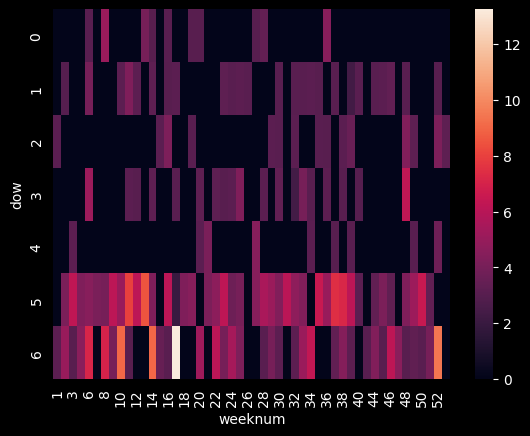

In [12]:
ax = sns.heatmap(piv)